# Projeto Prático: Machine Learning & Inteligência de Mercado
## Análise Estratégica da Concentração no Comércio Global de Bens Criativos (Dataset OpenFCS)

---

> **Componente Curricular:** Machine Learning aplicado à Administração

> **Instituição:** Curso de Graduação em Administração

> **Objetivo:** Aplicação prática de Ciência de Dados, Machine Learning e Inteligência Artificial Generativa para diagnosticar padrões de concentração e (re)configuração competitiva no comércio mundial de bens criativos, a partir do acervo aberto OpenFCS (UNCTAD, alinhado ao UNESCO Framework for Cultural Statistics 2025).

---

### Corpo Docente & Contato

| Atributo | Detalhes |
| :--- | :--- |
| **Professor** | **Sérgio Assunção Monteiro, D.Sc.** |
| **Conecte-se no LinkedIn** | [🌐 linkedin.com/in/sergio-assunção-monteiro](https://www.linkedin.com/in/sergio-assun%C3%A7%C3%A3o-monteiro-b781897b/) |
| **Currículo Lattes** | [🔬 lattes.cnpq.br/9489191035734025](http://lattes.cnpq.br/9489191035734025) |
| **Repositório GitHub** | [💻 github.com/sergiomonteiro76](https://github.com/sergiomonteiro76) |

---

### Sobre este Notebook
Este ambiente foi configurado para que os alunos atuem como **Analistas de Inteligência de Mercado**. Ao longo do semestre, com apoio de modelos de linguagem (IA) integrados ao ecossistema do Google Colab, vamos reconstruir — do dado bruto ao modelo preditivo — o diagnóstico de estrutura competitiva de um setor econômico real: o comércio internacional de bens criativos.

* **Fonte de dados:** [OpenFCS Dataset](https://doi.org/10.5281/zenodo.21211053) — Monteiro & Dubeux (2026), CC-BY-4.0.
* **Material de apoio:** Capítulos 1 a 3 das notas de aula (Ambiente e primeiro contato; Python/pandas/NumPy; Bases de Dados e SQL).

## Aula 11 — Ensembles e Otimização de Hiperparâmetros
Hoje não criamos um problema novo — retomamos os dois problemas dos capítulos anteriores (prever `log_total`, Aula 9; prever `degenerado`, Aula 10) e vemos se Random Forest e XGBoost superam os modelos mais simples. No caminho: uma demonstração direta de overfitting/underfitting, importância de features, e busca sistemática de hiperparâmetros (Grid Search vs. Random Search).

**recarregar o acervo — padrão validado**

In [16]:
import requests, zipfile, io, os
import pandas as pd
import numpy as np

url = (
    "https://zenodo.org/records/21211053/files/"
    "openfcs_v1.0.0.zip?download=1"
)
resp = requests.get(url)
resp.raise_for_status()

with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
    z.extractall("openfcs")

endereco = "openfcs/openfcs-1.0.0/data/derived/"
edges = pd.read_csv(endereco + "trade_edges.csv")
edges7 = edges[edges["resolution"] == "cer7"].copy()
spectral = pd.read_csv(endereco + "spectral_results.csv")

print(f"edges7:   {len(edges7):,} linhas")
print(f"spectral: {len(spectral):,} linhas")

edges7:   1,026,400 linhas
spectral: 322 linhas


### 11.1 Reconstruindo os dois problemas (Aulas 9 e 10)
Primeiro o problema de regressão (Aula 9): prever `log_total` por domínio-ano-economia, com split temporal.

In [17]:
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

tabela_ml = (
    edges7.groupby(["fcs_domain", "year", "economy"])["value_usd_millions"]
    .sum()
    .reset_index(name="total_economia")
)
tabela_ml["log_total"] = np.log1p(tabela_ml["total_economia"])
tabela_ml = tabela_ml[tabela_ml["economy"] != "G-77 (Group of 77)"].copy()

freq_economia = tabela_ml.groupby("economy")["total_economia"].sum()
tabela_ml["economy_freq"] = tabela_ml["economy"].map(freq_economia)

perfil_total = tabela_ml.pivot_table(
    index="economy", columns="fcs_domain", values="total_economia",
    aggfunc="sum", fill_value=0,
)
perfil_pct = perfil_total.div(perfil_total.sum(axis=1), axis=0)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
perfil_pct["cluster"] = kmeans.fit_predict(perfil_pct).astype(str)
tabela_ml["cluster"] = tabela_ml["economy"].map(perfil_pct["cluster"])

corte = 2020
colunas_x_reg = ["fcs_domain", "year", "economy_freq", "cluster"]
treino_reg = tabela_ml[tabela_ml["year"] < corte]
teste_reg = tabela_ml[tabela_ml["year"] >= corte]

Xr_treino, yr_treino = treino_reg[colunas_x_reg], treino_reg["log_total"]
Xr_teste, yr_teste = teste_reg[colunas_x_reg], teste_reg["log_total"]

print(f"Regressao -> treino: {len(Xr_treino):,} | teste: {len(Xr_teste):,}")

Regressao -> treino: 15,266 | teste: 4,083


**reconstrução do problema de classificação — Aula 10**

In [18]:
spectral7 = spectral[spectral["resolution"] == "cer7"].copy()
spectral7["razao_degenerescencia"] = (
    spectral7["lambda_min"].abs() / spectral7["lambda1"]
)
spectral7["degenerado"] = (
    spectral7["razao_degenerescencia"] > 0.9
).astype(int)

exportador_dominio_ano = (
    edges7.groupby(["fcs_domain", "year", "economy"])["value_usd_millions"]
    .sum()
    .reset_index(name="total_economia")
)
total_camada = exportador_dominio_ano.groupby(["fcs_domain", "year"])[
    "total_economia"
].transform("sum")
exportador_dominio_ano["participacao"] = (
    exportador_dominio_ano["total_economia"] / total_camada
)
hhi_por_dominio_ano = (
    exportador_dominio_ano.groupby(["fcs_domain", "year"])["participacao"]
    .apply(lambda s: (s ** 2).sum())
    .reset_index(name="HHI")
)

base = spectral7.merge(
    hhi_por_dominio_ano, on=["fcs_domain", "year"], how="inner"
)
colunas_x_clf = ["fcs_domain", "year", "n_economies", "n_edges", "HHI"]
Xc = base[colunas_x_clf]
yc = base["degenerado"]

Xc_treino, Xc_teste, yc_treino, yc_teste = train_test_split(
    Xc, yc, test_size=0.25, stratify=yc, random_state=42
)
print(f"Classificacao -> treino: {len(Xc_treino)} | teste: {len(Xc_teste)}")

Classificacao -> treino: 120 | teste: 41


**os dois ColumnTransformers das Aulas 9 e 10**

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pre_regressao = ColumnTransformer(transformers=[
    (
        "categorica",
        OneHotEncoder(handle_unknown="ignore"),
        ["fcs_domain", "cluster"],
    ),
    ("numerica", StandardScaler(), ["year", "economy_freq"]),
])

pre_classificacao = ColumnTransformer(transformers=[
    (
        "categorica",
        OneHotEncoder(handle_unknown="ignore"),
        ["fcs_domain"],
    ),
    (
        "numerica",
        StandardScaler(),
        ["year", "n_economies", "n_edges", "HHI"],
    ),
])

### 11.2 Overfitting e underfitting, ao vivo
Vamos variar a profundidade máxima da árvore de decisão da Aula 10 (que usou `max_depth=4`) e observar o desempenho em treino e teste separadamente. O padrão clássico: se treino sobe e teste cai (ou estagna), é overfitting.

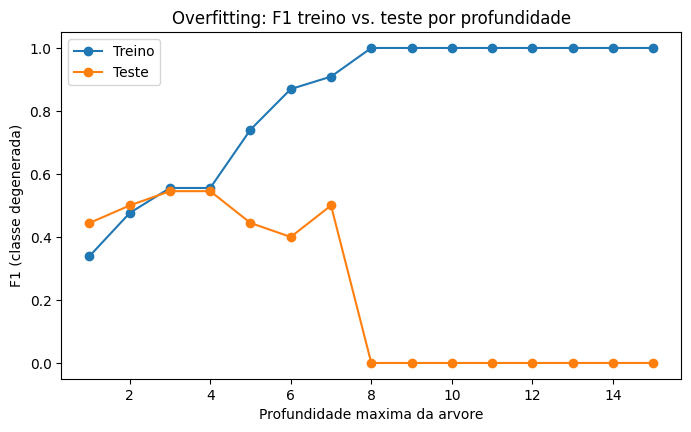

In [20]:
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

profundidades = range(1, 16)
f1_treino_lista, f1_teste_lista = [], []

for prof in profundidades:
    modelo = Pipeline(steps=[
        ("preprocessamento", pre_classificacao),
        (
            "modelo",
            DecisionTreeClassifier(
                max_depth=prof, class_weight="balanced", random_state=42
            ),
        ),
    ])
    modelo.fit(Xc_treino, yc_treino)
    f1_treino_lista.append(f1_score(yc_treino, modelo.predict(Xc_treino)))
    f1_teste_lista.append(f1_score(yc_teste, modelo.predict(Xc_teste)))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(list(profundidades), f1_treino_lista, marker="o", label="Treino")
ax.plot(list(profundidades), f1_teste_lista, marker="o", label="Teste")
ax.set_xlabel("Profundidade maxima da arvore")
ax.set_ylabel("F1 (classe degenerada)")
ax.set_title("Overfitting: F1 treino vs. teste por profundidade")
ax.legend()
plt.show()

### 11.3 Bagging e Random Forest: conceito
*Bagging* (*bootstrap aggregating*) treina várias árvores em amostras aleatórias (com reposição) dos dados, e combina as previsões (média, na regressão; voto, na classificação). Random Forest adiciona uma segunda fonte de aleatoriedade: cada divisão de cada árvore só considera um subconjunto aleatório das features. O resultado é um conjunto de árvores diferentes entre si, cujos erros tendem a se cancelar.

### 11.4 Random Forest para regressão

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

modelo_rf_reg = Pipeline(steps=[
    ("preprocessamento", pre_regressao),
    (
        "modelo",
        RandomForestRegressor(
            n_estimators=200, max_depth=8, random_state=42, n_jobs=-1
        ),
    ),
])
modelo_rf_reg.fit(Xr_treino, yr_treino)
pred_rf_reg = modelo_rf_reg.predict(Xr_teste)

print(f"R2 Random Forest (regressao): {r2_score(yr_teste, pred_rf_reg):.4f}")
print(f"R2 Linear, Aula 9 (referencia): 0.3737")

R2 Random Forest (regressao): 0.9199
R2 Linear, Aula 9 (referencia): 0.3737


### 11.5 Random Forest para classificação

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

modelo_rf_clf = Pipeline(steps=[
    ("preprocessamento", pre_classificacao),
    (
        "modelo",
        RandomForestClassifier(
            n_estimators=200, max_depth=6,
            class_weight="balanced", random_state=42, n_jobs=-1,
        ),
    ),
])
modelo_rf_clf.fit(Xc_treino, yc_treino)
pred_rf_clf = modelo_rf_clf.predict(Xc_teste)

print(classification_report(yc_teste, pred_rf_clf, zero_division=0))
print("F1 arvore unica, Aula 10 (referencia): 0.545")

              precision    recall  f1-score   support

           0       0.93      1.00      0.96        37
           1       1.00      0.25      0.40         4

    accuracy                           0.93        41
   macro avg       0.96      0.62      0.68        41
weighted avg       0.93      0.93      0.91        41

F1 arvore unica, Aula 10 (referencia): 0.545


### 11.6 Boosting e XGBoost: conceito
*Boosting* treina árvores em sequência, não em paralelo: cada nova árvore foca nos erros que as anteriores deixaram passar. XGBoost é uma implementação otimizada de *gradient boosting*, com regularização embutida para conter overfitting.

In [23]:
!pip install xgboost --quiet
from xgboost import XGBRegressor

modelo_xgb_reg = Pipeline(steps=[
    ("preprocessamento", pre_regressao),
    (
        "modelo",
        XGBRegressor(
            n_estimators=200, max_depth=4, learning_rate=0.1,
            random_state=42,
        ),
    ),
])
modelo_xgb_reg.fit(Xr_treino, yr_treino)
pred_xgb_reg = modelo_xgb_reg.predict(Xr_teste)

print(f"R2 XGBoost (regressao): {r2_score(yr_teste, pred_xgb_reg):.4f}")

R2 XGBoost (regressao): 0.9273


### 11.7 XGBoost para classificação, com peso de classe
`scale_pos_weight` é o equivalente, no XGBoost, ao `class_weight="balanced"` da Aula 10 — compensa o desbalanceamento sem duplicar linhas.

In [24]:
from xgboost import XGBClassifier

peso_positivo = (yc_treino == 0).sum() / (yc_treino == 1).sum()
print(f"scale_pos_weight calculado: {peso_positivo:.2f}")

modelo_xgb_clf = Pipeline(steps=[
    ("preprocessamento", pre_classificacao),
    (
        "modelo",
        XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.1,
            scale_pos_weight=peso_positivo,
            random_state=42, eval_metric="logloss",
        ),
    ),
])
modelo_xgb_clf.fit(Xc_treino, yc_treino)
pred_xgb_clf = modelo_xgb_clf.predict(Xc_teste)

print(classification_report(yc_teste, pred_xgb_clf, zero_division=0))

scale_pos_weight calculado: 11.00
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        37
           1       1.00      0.50      0.67         4

    accuracy                           0.95        41
   macro avg       0.97      0.75      0.82        41
weighted avg       0.95      0.95      0.94        41



### 11.8 Importância de features
Modelos baseados em árvore expõem `feature_importances_`: quanto cada variável, em média, contribuiu para reduzir a impureza (ou o erro) ao longo de todas as árvores.

In [25]:
nomes_features_reg = modelo_rf_reg.named_steps[
    "preprocessamento"
].get_feature_names_out()
importancias_reg = modelo_rf_reg.named_steps["modelo"].feature_importances_

pd.DataFrame({
    "feature": nomes_features_reg, "importancia": importancias_reg
}).sort_values("importancia", ascending=False)

,feature,importancia
11,numerica__economy_freq,0.608995
2,categorica__fcs_domain_C. Visual arts (crafts)...,0.188412
5,categorica__fcs_domain_F. Design and creative ...,0.079844
0,categorica__fcs_domain_A. Cultural and natural...,0.056052
6,categorica__cluster_0,0.019954
3,categorica__fcs_domain_D. Books and press,0.019013
10,numerica__year,0.008672
1,categorica__fcs_domain_B. Performance and cele...,0.006445
4,categorica__fcs_domain_E. Audiovisual and inte...,0.004581
9,categorica__cluster_3,0.004051


In [26]:
nomes_features_clf = modelo_rf_clf.named_steps[
    "preprocessamento"
].get_feature_names_out()
importancias_clf = modelo_rf_clf.named_steps["modelo"].feature_importances_

pd.DataFrame({
    "feature": nomes_features_clf, "importancia": importancias_clf
}).sort_values("importancia", ascending=False)

,feature,importancia
9,numerica__HHI,0.274834
8,numerica__n_edges,0.263406
7,numerica__n_economies,0.207251
6,numerica__year,0.131658
5,categorica__fcs_domain_F. Design and creative ...,0.044701
0,categorica__fcs_domain_A. Cultural and natural...,0.035668
4,categorica__fcs_domain_E. Audiovisual and inte...,0.034571
2,categorica__fcs_domain_C. Visual arts (crafts)...,0.003707
1,categorica__fcs_domain_B. Performance and cele...,0.002321
3,categorica__fcs_domain_D. Books and press,0.001884


### 11.9 Grid Search: busca exaustiva de hiperparâmetros

In [ ]:
from sklearn.model_selection import GridSearchCV

grade_parametros = {
    "modelo__n_estimators": [100, 200, 300],
    "modelo__max_depth": [4, 6, 8],
}

busca_grid = GridSearchCV(
    modelo_rf_clf, grade_parametros, scoring="f1", cv=5, n_jobs=-1
)
busca_grid.fit(Xc_treino, yc_treino)

print(f"Melhores parametros: {busca_grid.best_params_}")
print(f"Melhor F1 (validacao): {busca_grid.best_score_:.3f}")
print(f"Numero de combinacoes testadas: {len(busca_grid.cv_results_['params'])}")

### 11.10 Random Search: busca aleatória
Com muitos hiperparâmetros, testar todas as combinações fica caro. `RandomizedSearchCV` amostra um número fixo de combinações aleatórias — geralmente encontra um resultado quase tão bom, com uma fração do custo.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

distribuicoes = {
    "modelo__n_estimators": randint(50, 400),
    "modelo__max_depth": randint(2, 12),
}

busca_aleatoria = RandomizedSearchCV(
    modelo_rf_clf, distribuicoes, n_iter=10,
    scoring="f1", cv=5, random_state=42, n_jobs=-1,
)
busca_aleatoria.fit(Xc_treino, yc_treino)

print(f"Melhores parametros: {busca_aleatoria.best_params_}")
print(f"Melhor F1 (validacao): {busca_aleatoria.best_score_:.3f}")
print(f"Numero de combinacoes testadas: 10 (vs. {len(busca_grid.cv_results_['params'])} no grid)")

### 11.11 Comparativo final

In [ ]:
from sklearn.metrics import mean_absolute_error

def metricas_reg(y_real, y_prev, nome):
    return {
        "modelo": nome,
        "RMSE": np.sqrt(mean_squared_error(y_real, y_prev)),
        "MAE": mean_absolute_error(y_real, y_prev),
        "R2": r2_score(y_real, y_prev),
    }

resultados_reg = pd.DataFrame([
    metricas_reg(yr_teste, pred_rf_reg, "Random Forest"),
    metricas_reg(yr_teste, pred_xgb_reg, "XGBoost"),
])
resultados_reg

**classificação**

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

def metricas_clf(y_real, y_prev, nome):
    return {
        "modelo": nome,
        "acuracia": accuracy_score(y_real, y_prev),
        "precision": precision_score(y_real, y_prev, zero_division=0),
        "recall": recall_score(y_real, y_prev, zero_division=0),
        "f1": f1_score(y_real, y_prev, zero_division=0),
    }

resultados_clf = pd.DataFrame([
    metricas_clf(yc_teste, pred_rf_clf, "Random Forest"),
    metricas_clf(yc_teste, pred_xgb_clf, "XGBoost"),
    metricas_clf(
        yc_teste, busca_grid.best_estimator_.predict(Xc_teste),
        "RF + Grid Search",
    ),
])
resultados_clf.sort_values("f1", ascending=False)

## 🧪 Exercícios Práticos — Aula 11

> **Como usar:** resolva cada exercício em uma célula de código abaixo do enunciado. Depois, leve o resultado para uma IA usando o *prompt sugerido*.

---

### Exercício 1 — Onde exatamente começa o overfitting?
**📝 Tarefa:** Observando o gráfico da Célula 9, identifique a partir de qual profundidade a curva de teste para de melhorar (ou piora) enquanto a de treino continua subindo. Esse ponto seria uma boa escolha de `max_depth`?

**🤖 Pergunte à IA:**
> "No meu gráfico de F1 por profundidade, o treino sobe continuamente mas o teste [descreva o padrão]. A partir de que profundidade eu diria que o modelo começou a decorar o treino em vez de aprender?"

---

### Exercício 2 — Random Forest venceu a árvore única?
**📝 Tarefa:** Compare o F1 do Random Forest (Célula 13) com o da árvore única da Aula 10 (0,545). O ganho (se houver) justifica a complexidade adicional de treinar 200 árvores em vez de uma?

**🤖 Pergunte à IA:**
> "Meu Random Forest teve F1=[X] contra F1=0,545 de uma única árvore de decisão. Em que contexto de negócio vale a pena usar um modelo mais complexo por um ganho pequeno, e em que contexto não vale?"

---

### Exercício 3 — Comparando importância de features entre modelos
**📝 Tarefa:** Compare a tabela de importância de features do Random Forest de classificação (Célula 20) com o ranking de coeficientes da regressão logística da Aula 10. As variáveis mais influentes são as mesmas?

**🤖 Pergunte à IA:**
> "No Random Forest, a feature mais importante foi [X]; na regressão logística da aula anterior, a feature com maior coeficiente absoluto foi [Y]. Se forem diferentes, o que isso pode indicar sobre relações não lineares nos dados?"

---

### Exercício 4 — Grid vs. Random Search: o trade-off na prática
**📝 Tarefa:** Meça o tempo de execução das Células 22 e 24 (`%%time` no início da célula). O Random Search encontrou um F1 próximo do Grid Search gastando quanto tempo a menos, proporcionalmente?

**🤖 Pergunte à IA:**
> "Meu Grid Search testou [N] combinações em [X] segundos e encontrou F1=[A]. Meu Random Search testou 10 combinações em [Y] segundos e encontrou F1=[B]. Em que situações essa diferença de custo justificaria escolher Random Search mesmo com um resultado um pouco pior?"

---

### Exercício 5 — XGBoost sem `scale_pos_weight`
**📝 Tarefa:** Repita a Célula 17 sem definir `scale_pos_weight` (ou definindo como 1). O que acontece com o recall da classe degenerada? Isso lembra algum resultado da Aula 10?

**🤖 Pergunte à IA:**
> "Ao remover o ajuste de peso de classe do XGBoost, meu recall da classe minoritária caiu de [X] para [Y]. Por que modelos de boosting, sem esse ajuste, também tendem a favorecer a classe majoritária?"